**객체인식 모델을 활용한 안면분류 모델 구현**

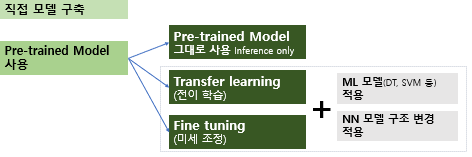

In [ ]:
import os
import json
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from keras.layers import GlobalAveragePooling2D, Dense, Dropout, Input
from keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from PIL import Image



In [ ]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  경로 설정 (각 환경에 따른 실제 경로로 변경)

BASE_DIR = '/content/drive/MyDrive/Face.Sent'
IMG_DIR = os.path.join(BASE_DIR, 'img')
LABEL_DIR = os.path.join(BASE_DIR, 'label')

In [ ]:
# JSON 파일에서 라벨(정답) 읽기
def load_labels(label_dir, dataset_type):
    label_path = os.path.join(label_dir, dataset_type)
    labels = {}
    for file_name in os.listdir(label_path):
        if file_name.endswith('.json'):
            with open(os.path.join(label_path, file_name), 'r', encoding='euc-kr') as f:
                data = json.load(f)
                for item in data:
                    filename = item['filename']
                    face_exp = item['faceExp_uploader'] # 이미지 정답 정보(감정)
                    labels[filename] = face_exp         # 파일명과 라벨 매칭
    return labels


In [ ]:
# 학습 데이터(이미지) 준비
def prepare_dataset(img_dir, labels, img_size=(128, 128)):
    images, targets = [], []
    for root, _, files in os.walk(img_dir):
        for file in files:
            if file in labels:  # JSON에 존재하는 파일만 사용
                img_path = os.path.join(root, file)
                image = Image.open(img_path).convert('RGB')
                image = image.resize(img_size)
                images.append(np.array(image))
                targets.append(labels[file])
    return np.array(images), np.array(targets)

In [ ]:
# 라벨(정답) 로드
train_labels = load_labels(LABEL_DIR, 'train')
val_labels = load_labels(LABEL_DIR, 'val')
test_labels = load_labels(LABEL_DIR, 'test')

In [ ]:
len(train_labels)

5994

In [ ]:
IMG_SIZE = (224, 224)  # 사전 학습 모형의 기본 해상도에 따라 조절 필요...

In [ ]:
#### 이미지/라벨 준비
train_images, train_targets = prepare_dataset(os.path.join(IMG_DIR, 'train'), train_labels, IMG_SIZE)
val_images, val_targets = prepare_dataset(os.path.join(IMG_DIR, 'val'), val_labels, IMG_SIZE)
test_images, test_targets = prepare_dataset(os.path.join(IMG_DIR, 'test'), test_labels, IMG_SIZE)

array([[[174, 176, 167],
        [173, 173, 163],
        [169, 170, 160],
        ...,
        [217, 219, 217],
        [219, 221, 218],
        [218, 218, 216]],

       [[176, 177, 169],
        [175, 175, 165],
        [171, 171, 161],
        ...,
        [219, 221, 219],
        [219, 221, 218],
        [220, 220, 218]],

       [[178, 179, 171],
        [177, 178, 168],
        [175, 175, 165],
        ...,
        [222, 224, 223],
        [221, 223, 220],
        [220, 222, 219]],

       ...,

       [[203, 205, 200],
        [220, 222, 217],
        [220, 222, 217],
        ...,
        [ 42,  41,  37],
        [ 39,  39,  36],
        [ 41,  39,  38]],

       [[219, 221, 216],
        [204, 205, 200],
        [221, 223, 218],
        ...,
        [ 47,  46,  43],
        [ 44,  44,  42],
        [ 44,  41,  40]],

       [[235, 237, 232],
        [204, 205, 200],
        [212, 213, 208],
        ...,
        [ 48,  47,  45],
        [ 49,  48,  46],
        [ 48,  44,  44]]], dtype=uint8)
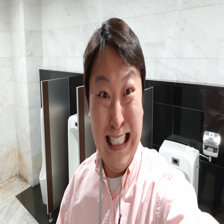

In [ ]:
train_images[0]

In [ ]:
 ###  라벨 인코딩 및 one-hot 변환
le = LabelEncoder()

train_targets = to_categorical(le.fit_transform(train_targets))
val_targets = to_categorical(le.transform(val_targets))
test_targets = to_categorical(le.transform(test_targets))

print(le.classes_)

['기쁨' '당황' '분노' '슬픔']


In [ ]:
NUM_CLASSES = train_targets.shape[1]  # 4개 감정 클래스
NUM_CLASSES


4

In [ ]:
# 3. 데이터 확인
print(f"Train 데이터 크기: {train_images.shape}, 라벨 크기: {train_targets.shape}")
print(f"Validation 데이터 크기: {val_images.shape}, 라벨 크기: {val_targets.shape}")
print(f"Test 데이터 크기: {test_images.shape}, 라벨 크기: {test_targets.shape}")


Train 데이터 크기: (5994, 224, 224, 3), 라벨 크기: (5994, 4)
Validation 데이터 크기: (1200, 224, 224, 3), 라벨 크기: (1200, 4)
Test 데이터 크기: (1200, 224, 224, 3), 라벨 크기: (1200, 4)


In [ ]:
##################################
####### 자체 모델 구축  ##########
##################################

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential

In [ ]:
# 모델 설계
def build_cnn_model(input_shape, num_classes):
    model = Sequential()

    # 첫 번째 CNN 블록
    model.add(Conv2D(64, (3, 3), activation='relu', input_shape=input_shape, padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 두 번째 CNN 블록
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 세 번째 CNN 블록
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # 네 번째 CNN 블록
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # fc 레이어
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

In [ ]:
# 모델 컴파일
INPUT_SHAPE = (224, 224, 3)

model = build_cnn_model(INPUT_SHAPE, NUM_CLASSES)

model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# 모델 요약
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 56,075,844 (213.91 MB)

 Trainable params: 56,072,004 (213.90 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [ ]:
# 모델 학습
history = model.fit(
    train_images, train_targets,
    validation_data=(val_images, val_targets),
    epochs=10,
    batch_size=32
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 180s 696ms/step - accuracy: 0.2426 - loss: 13.3078 - val_accuracy: 0.2442 - val_loss: 2.1813
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 84s 444ms/step - accuracy: 0.2501 - loss: 1.4434 - val_accuracy: 0.2508 - val_loss: 1.3887
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 142s 444ms/step - accuracy: 0.2439 - loss: 1.3896 - val_accuracy: 0.2525 - val_loss: 1.3875
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 437ms/step - accuracy: 0.2459 - loss: 1.3864 - val_accuracy: 0.2517 - val_loss: 1.3855
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 437ms/step - accuracy: 0.2469 - loss: 1.3855 - val_accuracy: 0.2500 - val_loss: 1.3868
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 435ms/step - accuracy: 0.2432 - loss: 1.3850 - val_accuracy: 0.2508 - val_loss: 1.3860
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 82s 437ms/step - accuracy: 0.2487 - loss: 1.3879 - val_accuracy: 0.2500 - val_loss: 1.3971
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 81s 433ms/step - accuracy: 0.2462 - loss

In [ ]:
# 모델 평가
test_loss, test_acc = model.evaluate(test_images, test_targets)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 136ms/step - accuracy: 0.2517 - loss: 1.3898
Test Accuracy: 0.2517, Test Loss: 1.3898


In [ ]:
##########################################################
####### 사전학습모형 - VGG16 사용, FC층 학습  ############
##########################################################

from tensorflow.keras.applications import VGG16

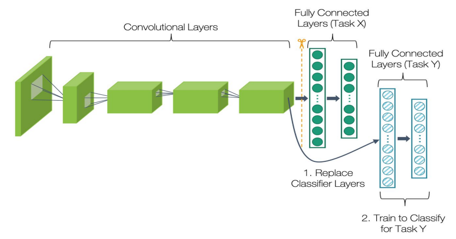

In [ ]:
# VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Conv 레이어 동결
for layer in base_model.layers:
    layer.trainable = False

# FC 레이어 추가 (출력층 포함)
model_vgg = models.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# 컴파일 / 학습
model_vgg.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model_vgg.fit(train_images, train_targets, validation_data=(val_images, val_targets), epochs=10, batch_size=32)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 58s 289ms/step - accuracy: 0.2524 - loss: 7.2439 - val_accuracy: 0.2433 - val_loss: 1.4675
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 233ms/step - accuracy: 0.2723 - loss: 1.4053 - val_accuracy: 0.2600 - val_loss: 1.4904
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 236ms/step - accuracy: 0.2728 - loss: 1.3798 - val_accuracy: 0.2558 - val_loss: 1.4585
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 235ms/step - accuracy: 0.2733 - loss: 1.3705 - val_accuracy: 0.2667 - val_loss: 1.5585
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 235ms/step - accuracy: 0.2746 - loss: 1.3734 - val_accuracy: 0.2475 - val_loss: 1.4444
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 234ms/step - accuracy: 0.2714 - loss: 1.3642 - val_accuracy: 0.2617 - val_loss: 1.4627
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 234ms/step - accuracy: 0.2793 - loss: 1.3719 - val_accuracy: 0.2508 - val_loss: 1.4563
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 44s 234ms/step - accuracy: 0.2741 - loss: 1

In [ ]:
# 모델 평가
test_loss, test_acc = model_vgg.evaluate(test_images, test_targets)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 191ms/step - accuracy: 0.2733 - loss: 1.3813
Test Accuracy: 0.2733, Test Loss: 1.3813


In [ ]:
# 모델 저장
model_vgg.save('/content/VGG16_model.h5')

In [ ]:
##########################################################
####### 사전학습모형 - ResNet 사용, FC층 학습  ###########
##########################################################

from tensorflow.keras.applications import ResNet50

In [ ]:
# ResNet 모델 불러오기 (사전 학습된 가중치 사용)
base_model = ResNet50(
    weights='imagenet',         # ImageNet 데이터로 사전 학습된 가중치
    include_top=False,          # Fully Connected 레이어 제외
    input_shape=(224, 224, 3)   # 입력 이미지 크기
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# Conv 레이어 동결
base_model.trainable = False

# FC 레이어 추가 (출력층 포함)
model_ResNet = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),        # GAP 레이어
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')  # 출력층
])

In [ ]:
# 모델 컴파일
model_ResNet.compile(
    optimizer=Adam(learning_rate=1e-3),  # 초기 학습률
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# 모델 학습
history = model_ResNet.fit(
    train_images, train_targets,
    validation_data=(val_images, val_targets),
    epochs=10,
    batch_size=32
)

Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 47s 182ms/step - accuracy: 0.3023 - loss: 1.4664 - val_accuracy: 0.3300 - val_loss: 1.3544
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 112ms/step - accuracy: 0.3358 - loss: 1.3290 - val_accuracy: 0.3475 - val_loss: 1.3235
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 107ms/step - accuracy: 0.3634 - loss: 1.3027 - val_accuracy: 0.3717 - val_loss: 1.2986
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 106ms/step - accuracy: 0.3824 - loss: 1.2847 - val_accuracy: 0.3767 - val_loss: 1.3051
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.3752 - loss: 1.2703 - val_accuracy: 0.3675 - val_loss: 1.3292
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 110ms/step - accuracy: 0.3871 - loss: 1.2648 - val_accuracy: 0.3842 - val_loss: 1.3223
Epoch 7/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step - accuracy: 0.3917 - loss: 1.2587 - val_accuracy: 0.3758 - val_loss: 1.3202
Epoch 8/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.3897 - loss: 1

In [ ]:
#  평가
test_loss, test_acc = model_ResNet.evaluate(test_images, test_targets)
print(f"Test Accuracy: {test_acc:.4f}, Test Loss: {test_loss:.4f}")


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.4050 - loss: 1.2445
Test Accuracy: 0.4050, Test Loss: 1.2445


In [ ]:
# 모델 저장
model.save('/content/model_ResNet.h5')


In [ ]:
##########################################################
####### 사전학습모형 - ResNet 사용 + FineTunning #########
##########################################################

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model


In [ ]:
### ResNet50 모델 로딩 (top 층 제외)
base_model = ResNet50(include_top=False, weights='imagenet', input_shape=(224, 224, 3))

In [ ]:
# 출력층 커스터마이징
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

model_ResNet2 = Model(inputs=base_model.input, outputs=output)

In [ ]:
model_ResNet2.summary()

Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_5[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 24,060,164 (91.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# conv 레이어 freeze (또는 일부 fine-tune 가능)
# for layer in base_model.layers:
#    layer.trainable = False

# conv5_x 블록 trainable
set_trainable = False
for layer in base_model.layers:
    if "conv5" in layer.name:
        set_trainable = True
    layer.trainable = set_trainable



In [ ]:
# 컴파일
model_ResNet2.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 학습
# model_ResNet2.fit(train_images, train_targets,
#          validation_data=(val_images, val_targets),
#          epochs=10,
#          batch_size=32)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

#### 학습
# 콜백 설정: 학습률 감소 / 조기 종료
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

history = model_ResNet2.fit(
    train_images, train_targets,
    validation_data=(val_images, val_targets),
    epochs=10,
    batch_size=32,
    callbacks=[reduce_lr, early_stop]
)




Epoch 1/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 67s 238ms/step - accuracy: 0.4825 - loss: 1.2125 - val_accuracy: 0.5467 - val_loss: 1.5678 - learning_rate: 0.0010
Epoch 2/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 29s 152ms/step - accuracy: 0.6733 - loss: 0.8319 - val_accuracy: 0.6167 - val_loss: 1.3952 - learning_rate: 0.0010
Epoch 3/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 149ms/step - accuracy: 0.7644 - loss: 0.6146 - val_accuracy: 0.6092 - val_loss: 1.2644 - learning_rate: 0.0010
Epoch 4/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 148ms/step - accuracy: 0.8462 - loss: 0.4299 - val_accuracy: 0.5667 - val_loss: 1.5960 - learning_rate: 0.0010
Epoch 5/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 149ms/step - accuracy: 0.8842 - loss: 0.3300 - val_accuracy: 0.5350 - val_loss: 2.3019 - learning_rate: 0.0010
Epoch 6/10
188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9251 - loss: 0.2108
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
188/188 ━━━━━━━━━━━━━━━━━━━━ 28s 149ms/step - accuracy: 0.923

In [ ]:
### 모델 평가
# conv5_x 블록 trainable  cf, conv 레이어 freeze
loss, acc = model_ResNet2.evaluate(test_images, test_targets)
print(f"테스트 정확도: {acc:.4f}")

38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.6267 - loss: 1.2086
테스트 정확도: 0.6267


In [ ]:
model_ResNet2.save('/content/model_ResNet2.h5')

In [ ]:
### 모델 TEST

from tensorflow.keras.preprocessing import image
import cv2

def predict_emotion(img_path, model, label_encoder, img_size=(224, 224)):
    # 이미지 불러오기
    img = image.load_img(img_path, target_size=img_size)

    # 전처리
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # 배치 차원 추가

    # 예측
    preds = model.predict(img_array)
    class_idx = np.argmax(preds)
    emotion = label_encoder.inverse_transform([class_idx])[0]
    confidence = np.max(preds)

    return emotion, confidence


In [ ]:
img_path = "/content/sad.JPG"                        #  이미지 경로
emotion_classes = ['기쁨', '당황', '분노', '슬픔']  # 클래스

label_encoder = LabelEncoder()
label_encoder.fit(emotion_classes)

emotion, confidence = predict_emotion(img_path, model_ResNet2, label_encoder)
print(f"예측 감정: {emotion} ({confidence:.2%})")